<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_7)_POS_Tag_HMM_Viterbi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 7)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### This notebook covers Part-of-Speech Tagging & Hidden Markov Models


## Outline

| # | Topic |
|---|---|
| 1 | What is Part-of-Speech (POS) tagging? |
| 2 | Markov chains |
| 3 | Hidden Markov Models (HMM) |
| 4 | Calculating transition & emission probabilities |
| 5 | Viterbi algorithm (init → forward → backward) |
| 6 | Code implementations |
| 7 | Coding Assignment |

### 1. What is Part-of-Speech Tagging?

**POS tagging** assigns a grammatical label to every word in a sentence.

**Example:**

```
Why  not   learn   something  ?
WRB  RB    VB      NN         .
```


**Goal:** given a sequence of words $w_1, w_2, \ldots, w_K$, find the **most probable** sequence of POS tags $t_1, t_2, \ldots, t_K$.

$$\hat{t}_{1:K} = \arg\max_{t_{1:K}} P(t_1, \ldots, t_K \mid w_1, \ldots, w_K)$$

### Common POS Tags

| Lexical Term | Tag | Example |
|---|---|---|
| Noun | NN | *something, nothing* |
| Verb | VB | *learn, study* |
| Determiner | DT | *the, a* |
| W-adverb | WRB | *why, where* |
| Adverb | RB | *not, quickly* |
| Punctuation | . | *.  ,  !* |

### Applications of POS Tagging

| Application | Description |
|---|---|
| **Named Entity Recognition** | Identify people, places, organisations |
| **Co-reference resolution** | Link pronouns to their referents |
| **Speech recognition** | Disambiguate homophones by grammar (look identical on lips when spoken), e.g., mat, pat, bat|
| **Machine translation** | Preserve grammatical structure across languages |

### Part of Speech Dependencies
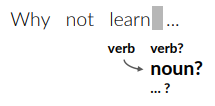


#### Most Likely Next Words
```
Why  not   learn   swimming  ?
           verb     noun     .
```
### Less Likely Words

```
Why  not   learn   swim  ?
            verb   verb  .
```

### Markov Chains

A **Markov chain** models a sequence of states where the probability of the next state depends **only on the current state** (Markov property).

- **States** represent POS tags: NN, VB, O (other)
- **Transitions** represent how likely one tag follows another
- Example: after *verb*, a *noun* is more likely than another *verb*



#### Markov Chain with $N=3$ states $Q = \{q_1, q_2, \dots, q_N\}$

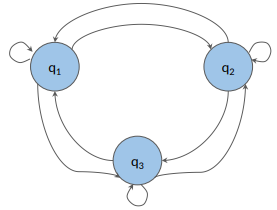



### Markov Chains (Visual Representation)

Arrows shows transitions while the numbers represent transition probability.

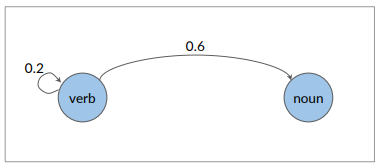



### POS tags as States with Transition probabilities

- Noun (NN)
- Verb (VB)
- Other (O)

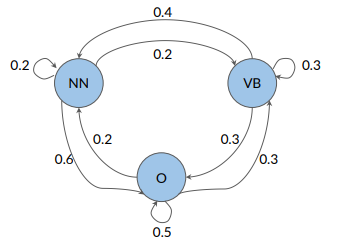

### Transition Probabilities

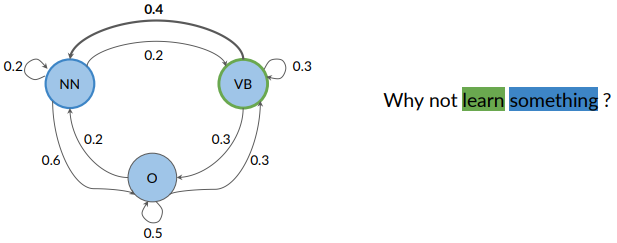

### Transition Matrix A

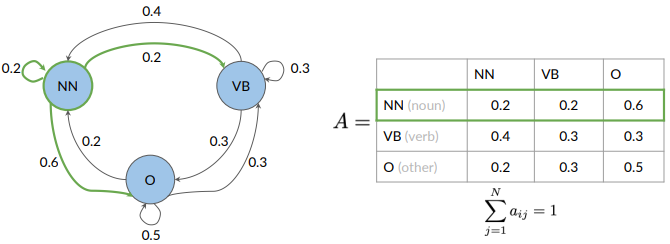


Each row sums to 1. Rows = current state; Columns = next state.



### Initial probabilities, Transition Table and Transition Matrix

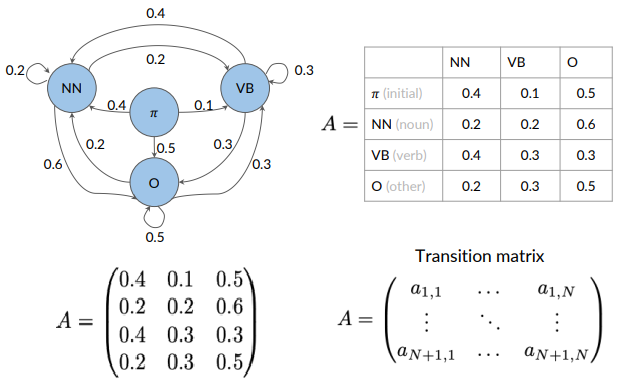


**π** = initial state distribution (probability of the *first* word's tag).

###  Hidden Markov Models (HMM) for POS Tagging

In an HMM, the **POS tags are hidden** (not directly observed). What we observe are the **words**.

- **Hidden states** = POS tags (NN, VB, O)
- **Observations** = words (*going, to, eat, …*)
- Each hidden state *emits* an observable word with some probability

### Emission Probabilities and Emission Matrix B

Probability that tag *t* generates word *w*:
$B[t, w] = P(w \mid t)$

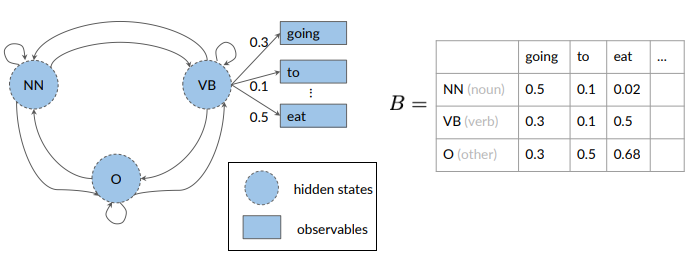

### Emission Probabilities and Emission Matrix B

Probability that tag *t* generates word *w*:
$B[t, w] = P(w \mid t)$

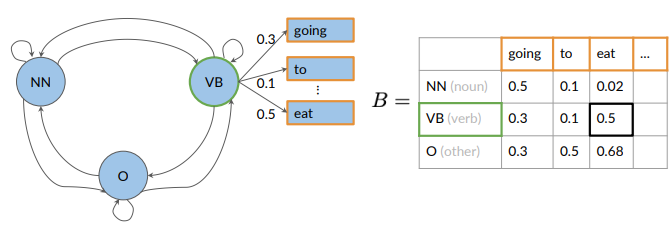

### Emission Matrix B

Probability that tag *t* generates word *w*:
$B[t, w] = P(w \mid t)$

| | **going** | **to** | **eat** | **…** |
|---|---|---|---|---|
| **NN (noun)** | 0.5 | 0.1 | 0.02 | … |
| **VB (verb)** | 0.3 | 0.1 | 0.5 | … |
| **O (other)** | 0.3 | 0.5 | 0.68 | … |

$$\sum_{j=1}^V b_{ij} = 1$$

**Example ambiguity:** *"He lay on his back"* vs *"I'll be back"* — *back* has different tags depending on context.

### HMM Summary

An HMM is fully defined by three components:

| Component | Symbol | Description |
|---|---|---|
| Initial probabilities | **π** | Prob. of each tag at position 1 (first row) |
| Transition matrix | **A** | Prob. of tag *i* following tag *i-1* |
| Emission matrix | **B** | Prob. of word *w* given tag *t* |

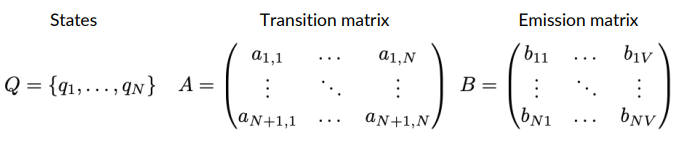

### Calculating Transition Probabilities

**Step 1 — Count tag-pair occurrences** in the training corpus.

- Count occurances of tag pairs: $\text{count}  (t_{i-1}, t_i)$

- Calculate probabilites using the counts:
$$A[t_{i-1}, t_i] = P(t_i \mid t_{i-1}) =
\frac{\text{count}(t_{i-1}, t_i) }
{\sum_{j=1}^N \text{count}(t_{i-1}, j) }$$


**Example** (Ezra Pound poem (1913) as corpus):

```
In a Station of the Metro
The apparition of these faces in the crowd :
Petals on a wet , black bough .
```
After lowercasing and adding `<s>` sentence starters
```
<s> in a station of the metro
<s> the apparition of these faces in the crowd
<s> petals on a wet , black bough .
```

### Populating the Transition Matrix

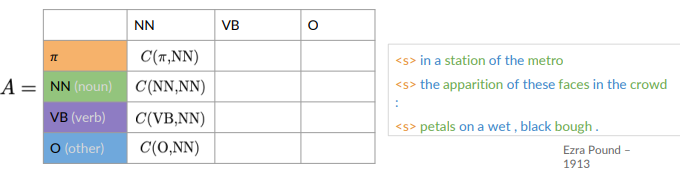


### Populating the Transition Matrix

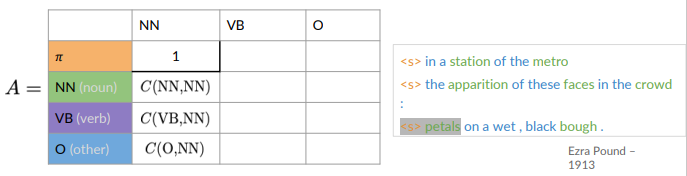

### Populating the Transition Matrix

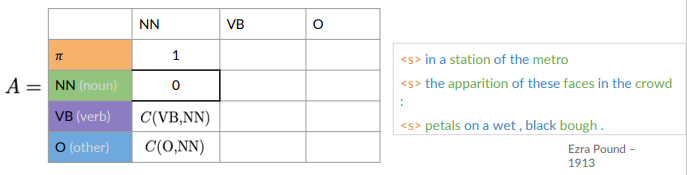

### Populating the Transition Matrix

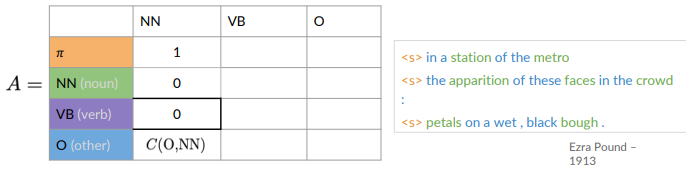

### Populating the Transition Matrix

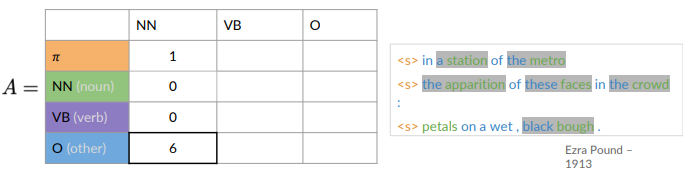

### Populating the Transition Matrix

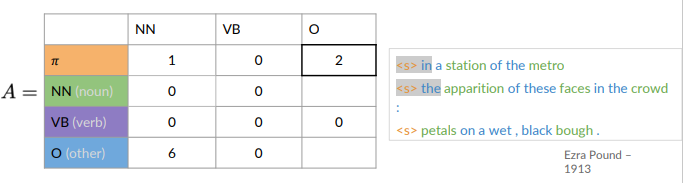

### Populating the Transition Matrix

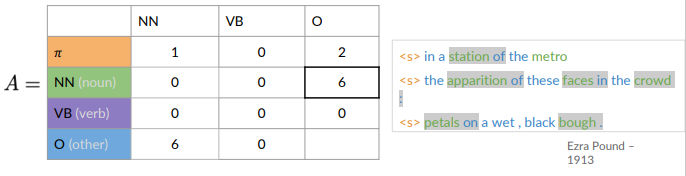

### Populating the Transition Matrix

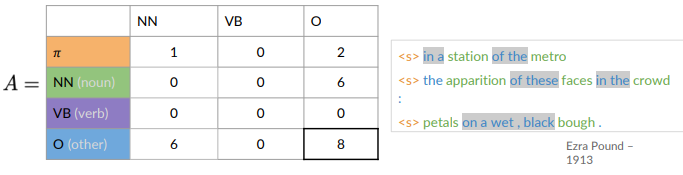

### Populating the Transition Matrix

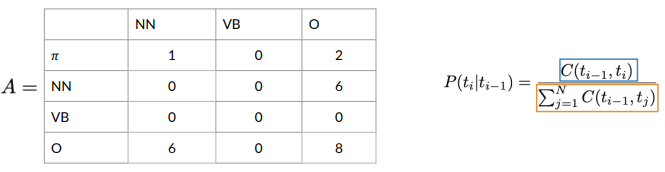

### Populating the Transition Matrix

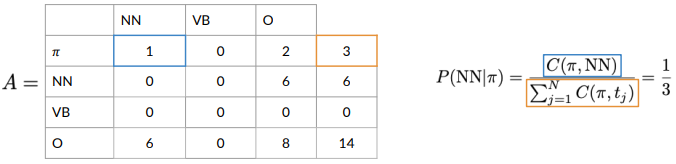

### Populating the Transition Matrix

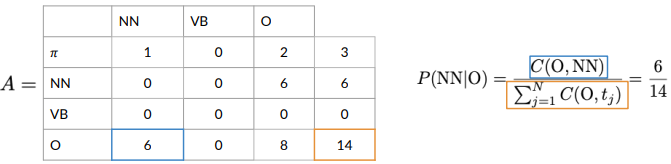

### Populating the Transition Matrix with Laplace Smoothing

Zero counts cause problems (division by zero, unseen transitions).

> Add a small constant (**ε** ≈ 0.001) to every cell.

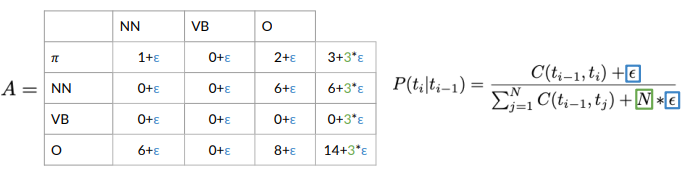

> *N* = number of states.

### Populating the Transition Matrix with Laplace Smoothing


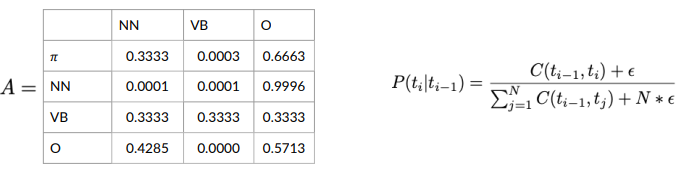

### Calculating Emission Probabilities

Count how often tag *t* is paired with word *w* in the training corpus:

$$B[t, w] = \frac{\text{count}(t, w)}{\text{count}(t)}$$

Emission count table for the poem corpus


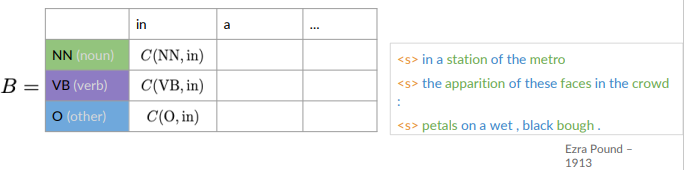


### Calculating Emission Probabilities

Count how often tag *t* is paired with word *w* in the training corpus:

$$B[t, w] = \frac{\text{count}(t, w)}{\text{count}(t)}$$

Emission count table for the poem corpus above




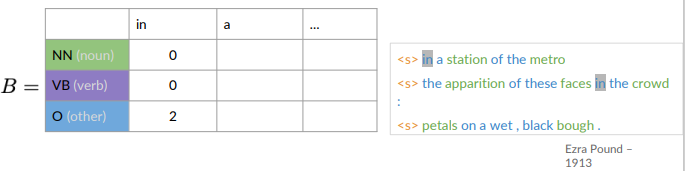

### Calculating Emission Probabilities with Smoothing

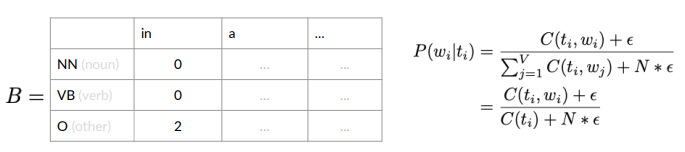

### The Viterbi Algorithm

**Goal:** given a sequence of observed words $w_1, w_2, \ldots, w_K$, find the most probable sequence of hidden POS tags $t_1, t_2, \ldots, t_K$.

$$\hat{t}_{1:K} = \arg\max_{t_{1:K}} P(t_1, \ldots, t_K \mid w_1, \ldots, w_K)$$

- Viterbi is a **dynamic programming** algorithm that runs in $O(N^2 K)$ time.

- Viterbi maintains two matrices of shape ($N$ tags × $K$ words):
| Matrix | Symbol | Meaning |
|---|---|---|
| **Viterbi / score** | $C$ | Best probability to reach state $i$ at word $j$ |
| **Backpointer** | $D$ | Index of the best previous state leading to $C[i,j]$ |

### The Viterbi Algorithm (A Graph Algorithm)

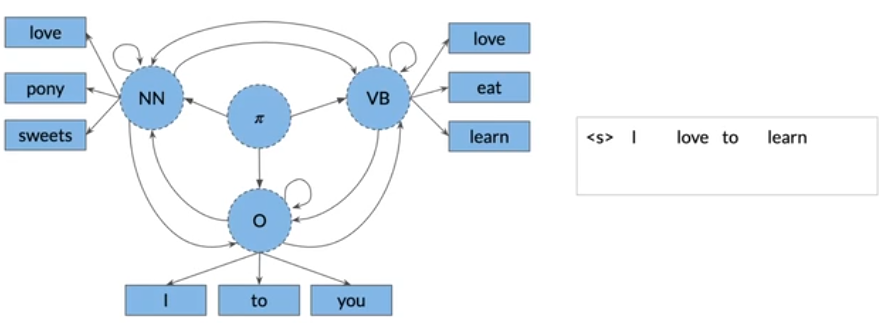

### The Viterbi Algorithm (A Graph Algorithm)

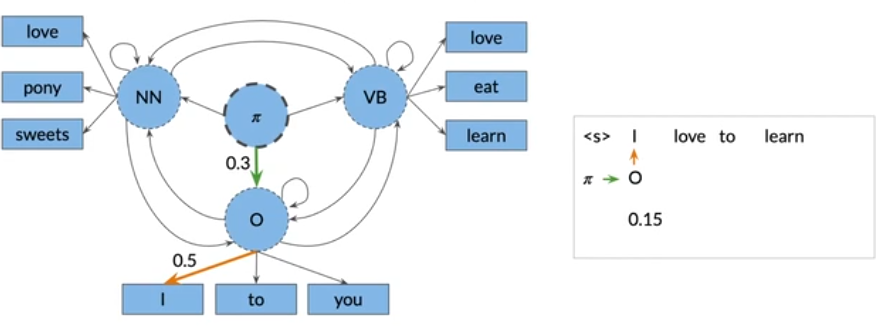

### The Viterbi Algorithm (A Graph Algorithm)

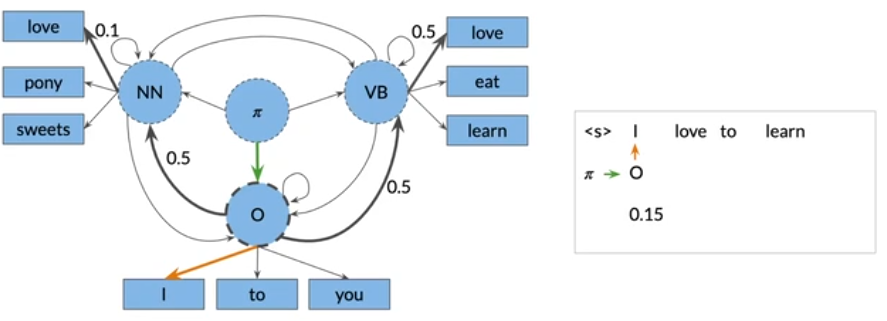

### The Viterbi Algorithm (A Graph Algorithm)

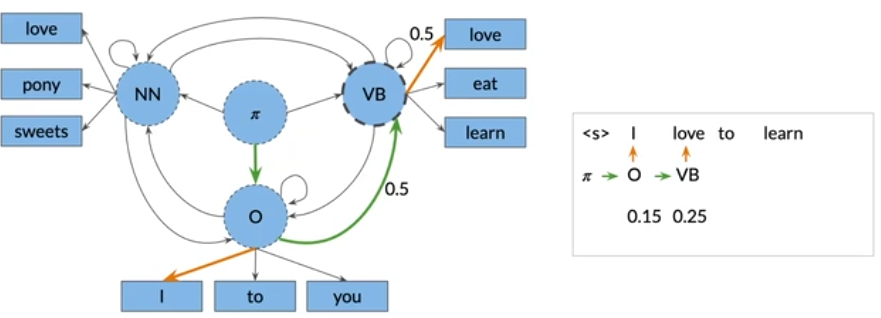

### The Viterbi Algorithm (A Graph Algorithm)

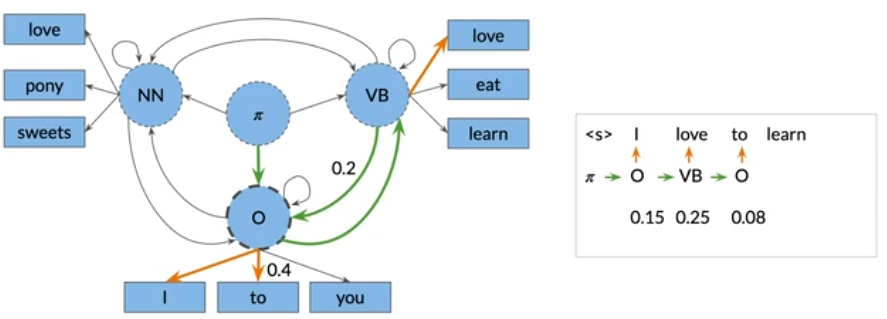

### The Viterbi Algorithm (A Graph Algorithm)

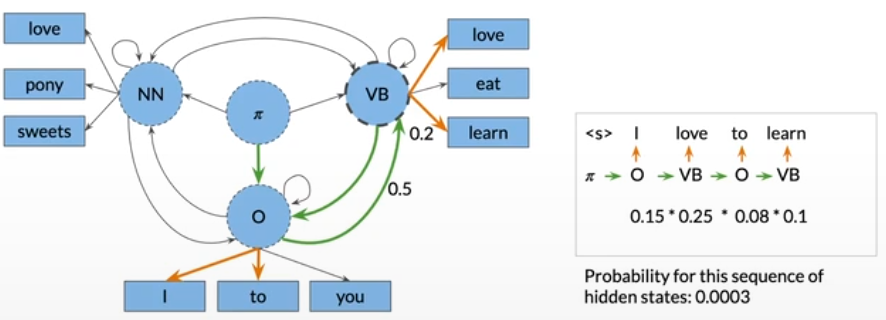

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi algorithm – Steps

1. Initialization step
2. Forward pass
3. Backward pass

Viterbi algorithm uses two auxiliary matrices:
-  matrix $C$ to keep track of probabilities that a word belongs to a POS tag.
- matrix $D$ to keep track of the optimal path

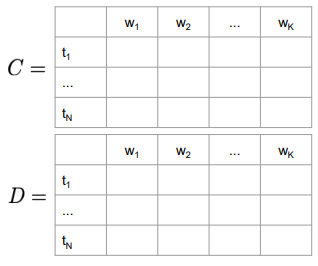

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: initialization step

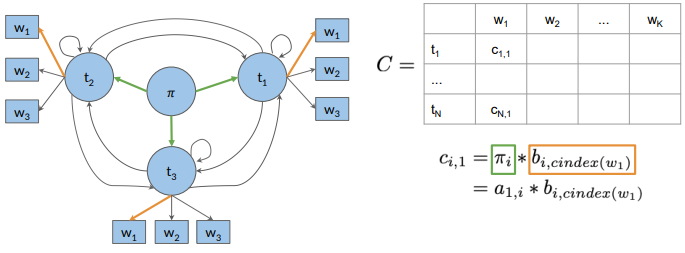

- $cindex(w_1)$ = column index of word $w_1$ in the $B$ matrix.

### The Viterbi Algorithm (A Graph Algorithm)

#### Step 1 — Initialisation

Fill column 1 (first word $w_1$) using the initial distribution $π$ and emission matrix $B$:

$$c_{i, 1} = \pi_i \cdot b_{i, cindex (w_1)}$$
$$d_{i, 1} = 0 \quad (\text{no previous state})$$

- Every row in column 1 is initialised independently from **π**.


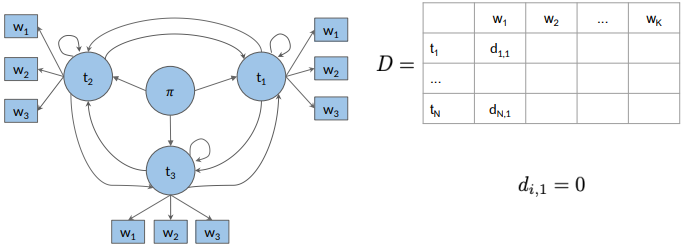


### The Viterbi Algorithm (A Graph Algorithm)
#### Step 2 — Forward Pass

For each subsequent word $w_j$ ($j = 2, \ldots, K$) and each tag $t_i$:

$$c_{i,j} = \max_k \; c_{k,\,j-1} \cdot a_{k,i} \cdot b_{i,\,{cindex}(w_j)}$$
$$
d_{i,j} = \arg\max_k \; c_{k,\,j-1} \cdot a_{k,i} \cdot b_{i,\,{cindex}(w_j)}$$

- $a_{k,i}$ = transition probability from tag $k$ to tag $i$  
- $b_{i,{cindex}(w_j)}$ = emission probability of word $w_j$ given tag $i$

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: forward pass

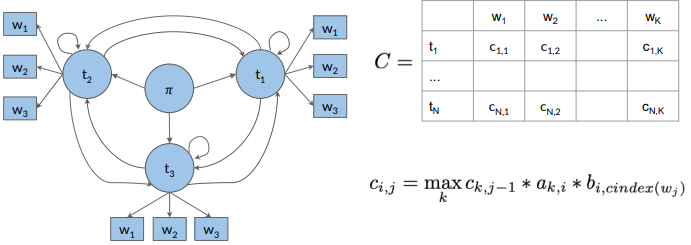


### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: forward pass

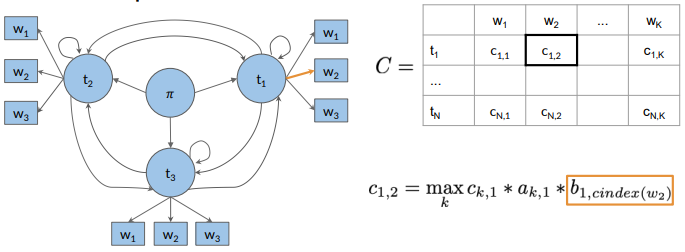

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: forward pass

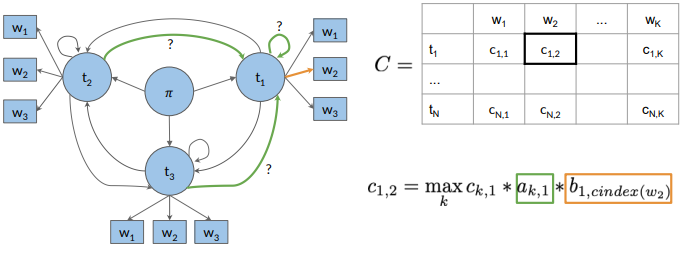


### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: forward pass

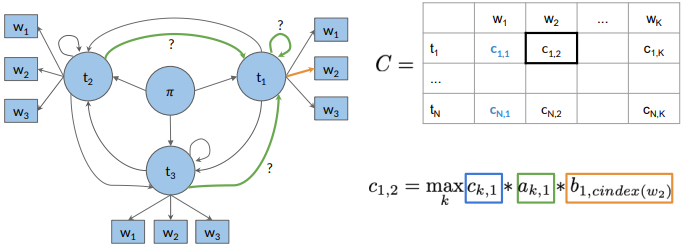

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: forward pass

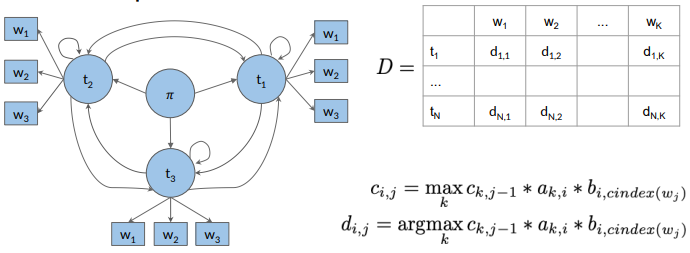

### The Viterbi Algorithm (A Graph Algorithm)

#### Step 3 — Backward Pass (Backtracing)

After filling both matrices:

1. **Find best final state:** $s^* = \arg\max_i c_{(i, K)}$
2. **Trace back** through **D** from column $K$ to column $1$ to recover the full tag sequence

$$s = \arg\max_i c_{i,K}$$

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

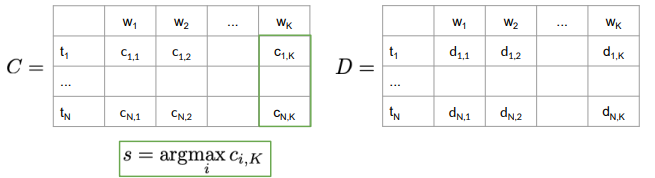

- $s$ is the index from column $K$ of matrix $C$ with maximum probability of the hidden states that generate the given sequence of input words.

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

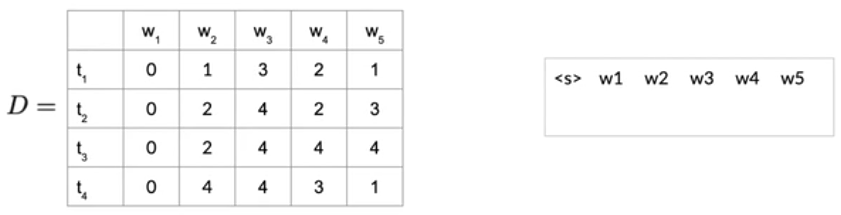

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

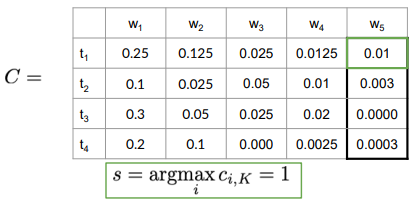


### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

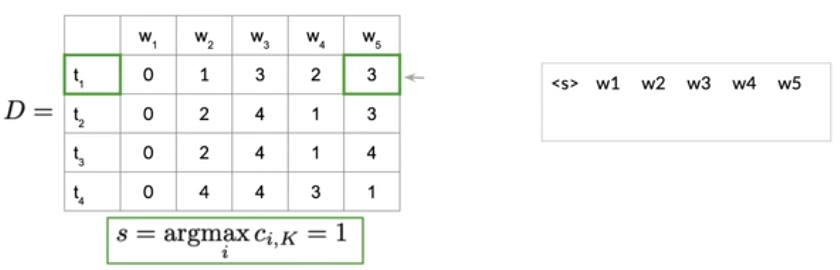

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

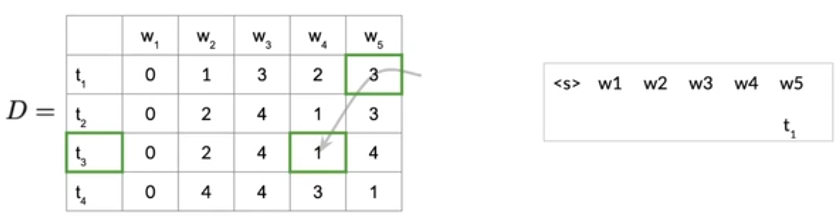

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

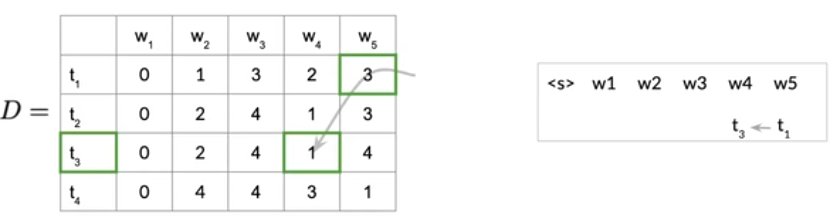

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

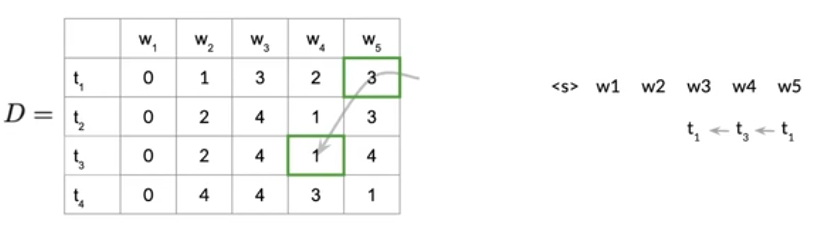

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass


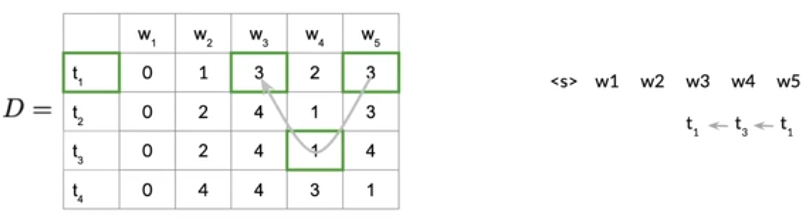

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass

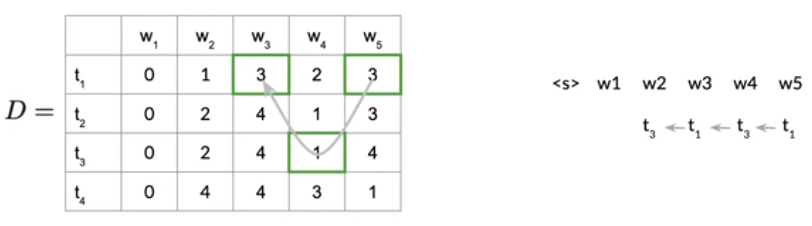

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass


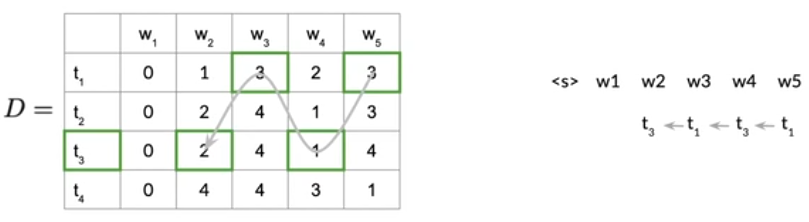

### The Viterbi Algorithm (A Graph Algorithm)

Viterbi: backward pass


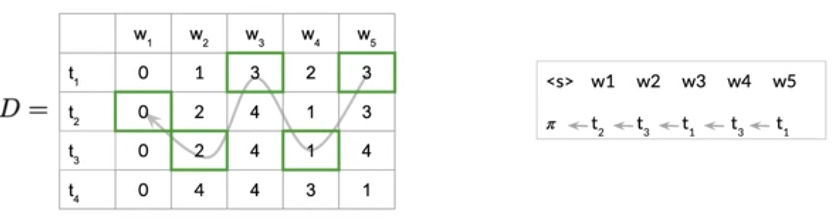


**Best path** (backtrace from $w_5$):  
$w_5 \to t_1$ (highest $C$) $\to d_{t_1,w_5}=3 \to t_3$ at $w_4$ $\to d_{t_3,w_4}=1 \to t_1$ at $w_3$ $\to \ldots$  

### The Viterbi Algorithm (A Graph Algorithm)

Implementation notes
1. In Python index starts with 0.
2. Use log probabilities.


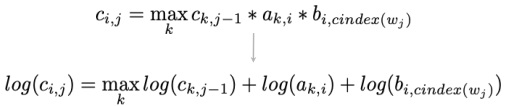

### Viterbi: Graph Intuition

For sentence `<s> I love to learn` with 3 tags {NN, VB, O}:

```
<s>   I       love    to      learn
 π → O(0.15) → O(0.25) → VB(0.08×0.1) → ...
              ↑
         π(O)=0.5 × B(O,'I')=0.3  =  0.15
```

One possible path probability: `0.15 × 0.25 × 0.08 × 0.1 = 0.0003`  
Viterbi finds the path with the **maximum** such product.

### Implementation Notes

| Note | Detail |
|---|---|
| Python indexing | Indices start at **0** (slides show 1-based) |
| Numerical underflow | Use **log probabilities** — replace × with + |
| Log-space formula | $\log c_{i,j} = \max_k \left[ \log c_{k,j-1} + \log a_{k,i} + \log b_{i,\text{index}(w_j)} \right]$ |

### Summary

| Concept | Key Idea |
|---|---|
| POS tagging | Assign grammar labels to every word |
| Markov chain | Next tag depends only on current tag |
| HMM | Tags are hidden; words are observable |
| Transition matrix A | P(tag j \| tag i), includes π |
| Emission matrix B | P(word w \| tag t) |
| Smoothing | Add ε to avoid zero probabilities |
| Viterbi | DP algo: init → forward pass → backward pass |
| Log probs | Avoid underflow; replace × with + |

### Code Implementations

In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict

# ── Toy tagged corpus ─────────────────────────────────────────────────────────
# Format: list of (word, tag) sentences
tagged_corpus = [
    [('<s>','--'), ('why','O'), ('not','O'), ('learn','VB'), ('something','NN')],
    [('<s>','--'), ('you','O'), ('eat','VB'), ('oatmeal','NN')],
    [('<s>','--'), ('the','O'), ('dog','NN'), ('runs','VB'), ('fast','O')],
    [('<s>','--'), ('learn','VB'), ('something','NN'), ('new','O')],
]

tags  = ['NN', 'VB', 'O']
words = sorted({w for sent in tagged_corpus for w, _ in sent if w != '<s>'})
print("Tags :", tags)
print("Vocab:", words)

Tags : ['NN', 'VB', 'O']
Vocab: ['dog', 'eat', 'fast', 'learn', 'new', 'not', 'oatmeal', 'runs', 'something', 'the', 'why', 'you']


In [ ]:
# ── Build Transition Matrix A (with Laplace smoothing) ───────────────────────
def build_transition_matrix(corpus, tags, epsilon=0.001):
    tag_to_i = {t: i for i, t in enumerate(tags)}
    N = len(tags)
    # +1 row for π (initial state)
    count = np.zeros((N + 1, N))

    for sent in corpus:
        prev_tag = '--'  # sentence start
        for _, tag in sent:
            if tag == '--':
                continue
            j = tag_to_i[tag]
            if prev_tag == '--':
                count[N, j] += 1      # π row
            else:
                i = tag_to_i[prev_tag]
                count[i, j] += 1
            prev_tag = tag

    # Laplace smoothing + normalise
    A = (count + epsilon) / (count.sum(axis=1, keepdims=True) + epsilon * N)
    return A

A = build_transition_matrix(tagged_corpus, tags)
idx = tags + ['π']
df_A = pd.DataFrame(A, index=idx, columns=tags)
print("Transition Matrix A (rows=from, cols=to):")
display(df_A.round(4))

Transition Matrix A (rows=from, cols=to):


,NN,VB,O
NN,0.0005,0.4998,0.4998
VB,0.7497,0.0002,0.2501
O,0.2501,0.4999,0.2501
π,0.0002,0.2501,0.7497


In [ ]:
# ── Build Emission Matrix B (with Laplace smoothing) ─────────────────────────
def build_emission_matrix(corpus, tags, vocab, epsilon=0.001):
    tag_to_i  = {t: i for i, t in enumerate(tags)}
    word_to_j = {w: j for j, w in enumerate(vocab)}
    N, V = len(tags), len(vocab)
    count = np.zeros((N, V))

    for sent in corpus:
        for word, tag in sent:
            if tag == '--' or word not in word_to_j:
                continue
            count[tag_to_i[tag], word_to_j[word]] += 1

    B = (count + epsilon) / (count.sum(axis=1, keepdims=True) + epsilon * V)
    return B

B = build_emission_matrix(tagged_corpus, tags, words)
df_B = pd.DataFrame(B, index=tags, columns=words)
print("Emission Matrix B (rows=tag, cols=word):")
display(df_B.round(4))

Emission Matrix B (rows=tag, cols=word):


,dog,eat,fast,learn,new,not,oatmeal,runs,something,the,why,you
NN,0.2495,0.0002,0.0002,0.0002,0.0002,0.0002,0.2495,0.0002,0.4988,0.0002,0.0002,0.0002
VB,0.0002,0.2495,0.0002,0.4988,0.0002,0.0002,0.0002,0.2495,0.0002,0.0002,0.0002,0.0002
O,0.0002,0.0002,0.1665,0.0002,0.1665,0.1665,0.0002,0.0002,0.0002,0.1665,0.1665,0.1665


In [ ]:
# ── Viterbi Algorithm (log-space) ─────────────────────────────────────────────
def viterbi(sentence, tags, A, B, words):
    """
    sentence : list of word strings
    A        : (N+1) x N  transition matrix  (last row = π)
    B        : N x V      emission matrix
    words    : vocabulary list (same order as B columns)
    Returns  : predicted tag list, C matrix (log-probs), D matrix (backptrs)
    """
    word_to_j = {w: j for j, w in enumerate(words)}
    N = len(tags)
    K = len(sentence)

    log_A = np.log(A + 1e-12)
    log_B = np.log(B + 1e-12)
    pi    = log_A[N, :]   # π is the last row of A

    C = np.full((N, K), -np.inf)
    D = np.zeros((N, K), dtype=int)

    # ── Initialisation ────────────────────────────────────────────────────────
    w0_idx = word_to_j.get(sentence[0], 0)
    C[:, 0] = pi + log_B[:, w0_idx]

    # ── Forward pass ──────────────────────────────────────────────────────────
    for j in range(1, K):
        wj_idx = word_to_j.get(sentence[j], 0)
        for i in range(N):
            scores  = C[:, j-1] + log_A[:N, i] + log_B[i, wj_idx]
            D[i, j] = np.argmax(scores)
            C[i, j] = scores[D[i, j]]

    # ── Backward pass ─────────────────────────────────────────────────────────
    best_tags = [0] * K
    best_tags[-1] = int(np.argmax(C[:, -1]))
    for j in range(K-2, -1, -1):
        best_tags[j] = D[best_tags[j+1], j+1]

    return [tags[t] for t in best_tags], C, D


sentence = ['why', 'not', 'learn', 'something']
predicted, C, D = viterbi(sentence, tags, A, B, words)

print("Sentence :", sentence)
print("Predicted:", predicted)
print()
print("C matrix (log-prob):")
display(pd.DataFrame(C, index=tags, columns=sentence).round(3))
print()
print("D matrix (backpointers):")
display(pd.DataFrame(D, index=tags, columns=sentence))

Sentence : ['why', 'not', 'learn', 'something']
Predicted: ['O', 'O', 'VB', 'NN']

C matrix (log-prob):


,why,not,learn,something
NN,-16.592,-11.764,-14.943,-7.632
VB,-9.683,-11.071,-6.649,-23.241
O,-2.081,-5.260,-15.347,-16.736



D matrix (backpointers):


,why,not,learn,something
NN,0,2,2,1
VB,0,2,2,1
O,0,2,2,1


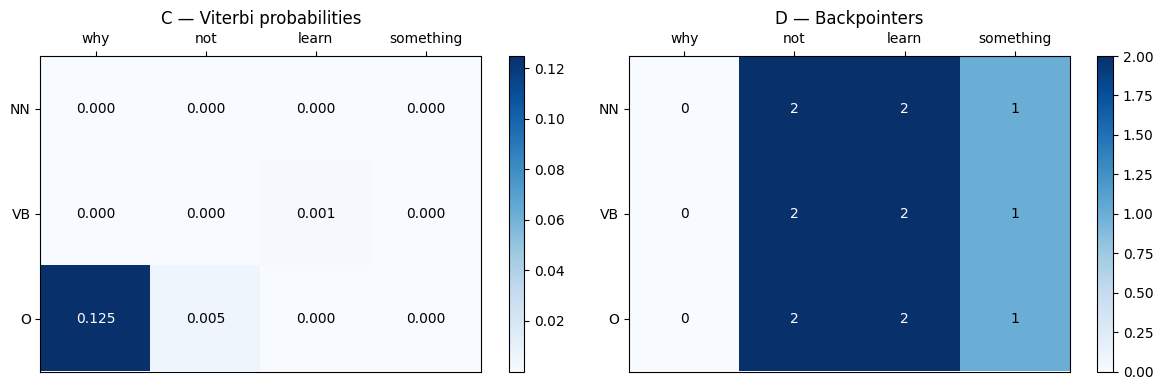

In [ ]:
# ── Visualise the Viterbi C matrix as a heatmap ──────────────────────────────
import matplotlib.pyplot as plt

def plot_viterbi(C, D, tags, sentence):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, mat, title, fmt in zip(
        axes,
        [np.exp(C), D],
        ['C — Viterbi probabilities', 'D — Backpointers'],
        ['.3f', 'd']
    ):
        im = ax.imshow(mat, cmap='Blues', aspect='auto')
        for i in range(len(tags)):
            for j in range(len(sentence)):
                val = mat[i, j]
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        fontsize=10, color='white' if val > mat.max()*0.6 else 'black')
        ax.set_xticks(range(len(sentence))); ax.set_xticklabels(sentence)
        ax.set_yticks(range(len(tags)));    ax.set_yticklabels(tags)
        ax.set_title(title); ax.xaxis.tick_top()
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_viterbi(C, D, tags, sentence)

In [ ]:
# ── Using NLTK's built-in POS tagger (production-quality) ────────────────────
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)

sentences = [
    "Why not learn something new today",
    "The quick brown fox jumps over the lazy dog",
]

for sent in sentences:
    tokens = nltk.word_tokenize(sent)
    tagged = nltk.pos_tag(tokens)
    print(f"Input : {sent}")
    print(f"Tagged: {tagged}")
    print()

Input : Why not learn something new today
Tagged: [('Why', 'WRB'), ('not', 'RB'), ('learn', 'VB'), ('something', 'NN'), ('new', 'JJ'), ('today', 'NN')]

Input : The quick brown fox jumps over the lazy dog
Tagged: [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN')]



### Coding Assignment — POS Tagging with HMM & Viterbi

In this assignment you will build a **Part-of-Speech tagger** using a Hidden Markov Model with the Viterbi decoding algorithm. You will work on the **Wall Street Journal** section of the Penn Treebank corpus.

**Learning outcomes:**
- Understand how to build the transition matrix **A** and emission matrix **B** from a tagged corpus
- Apply Laplace smoothing to handle unseen tag/word pairs
- Implement the three steps of the Viterbi algorithm: initialisation, forward pass, backward pass
- Use log probabilities to avoid numerical underflow

### Part 1 — Data Preparation

**1.1** Load the training corpus [`WSJ_02-21.pos`](https://cocalc.com/github/y33-j3T/Coursera-Deep-Learning/blob/master/Natural%20Language%20Processing%20with%20Probabilistic%20Models/Week%202%20-%20Part%20of%20Speech%20Tagging%20and%20Hidden%20Markov%20Models/WSJ_02-21.pos) (word/tag pairs, one per line, sentences separated by blank lines).


**1.2** Build the vocabulary:
- Count word frequencies in the training set.
- Replace words that appear **fewer than 2 times** with the token `--unk--`.
- Store all unique (lowercased) words as `vocab`.

**1.3** Preprocess the corpus:
- Lowercase all words.
- Add a start-of-sentence token `--s--` at the beginning of every sentence.
- Build two parallel lists: `prep` (preprocessed words) and `y` (corresponding tags).

### Part 2 — Build the Transition and Emission Matrices

**2.1** Count transition pairs:

```python
def create_counts(training_corpus, vocab):
    """
    Returns:
        emission_counts  : dict {(tag, word): count}
        transition_counts: dict {(prev_tag, tag): count}
        tag_counts       : dict {tag: count}
    """
```

Iterate over each consecutive (tag_{i-1}, tag_i, word_i) triple. Use `--s--` as the initial previous-tag for each sentence.

**2.2** Build transition matrix **A** of shape `(num_tags, num_tags)`:

```python
def create_transition_matrix(alpha, tag_counts, transition_counts):
    """
    A[i, j] = (transition_counts[(tags[i], tags[j])] + alpha)
              / (tag_counts[tags[i]] + alpha * num_tags)
    alpha: smoothing parameter (e.g. 0.001)
    """
```

**2.3** Build emission matrix **B** of shape `(num_tags, num_words)`:

```python
def create_emission_matrix(alpha, tag_counts, emission_counts, vocab):
    """
    B[i, j] = (emission_counts[(tags[i], vocab[j])] + alpha)
              / (tag_counts[tags[i]] + alpha * num_words)
    """
```

### Part 3 — Viterbi Algorithm

**3.1 Initialisation step:**

```python
def initialize(states, tag_counts, A, B, corpus, vocab):
    """
    For the first word w_0 in the sentence:
        best_probs[i, 0] = log(A['--s--', states[i]]) + log(B[states[i], w_0])
        best_paths[i, 0] = 0
    Returns best_probs, best_paths  (both shape: num_tags × len(corpus))
    """
```

**3.2 Forward pass:**

```python
def viterbi_forward(A, B, test_corpus, best_probs, best_paths, vocab):
    """
    For each word j = 1, ..., K-1 and each tag i:
        best_probs[i, j] = max_k [ best_probs[k, j-1]
                                  + log(A[k, i])
                                  + log(B[i, index(w_j)]) ]
        best_paths[i, j] = argmax_k [...]
    """
```

**3.3 Backward pass:**

```python
def viterbi_backward(best_probs, best_paths, corpus, states):
    """
    1. s = argmax_i best_probs[i, K-1]        # best tag for last word
    2. z[K-1] = s
    3. For j = K-2 down to 0:
           z[j] = best_paths[z[j+1], j+1]
    4. pred = [states[z[j]] for j in range(K)]
    Returns pred: list of predicted POS tags
    """
```

### Part 4 — Evaluation

**4.1** Compute accuracy on the test set `WSJ_24.pos`:

```python
def compute_accuracy(pred, y):
    """
    accuracy = (number of correct tag predictions) / (total tag predictions)
    Skip sentence-boundary tokens '--s--'.
    Expected accuracy on WSJ test set: ~95%
    """
```

**4.2** Report per-tag accuracy and identify the most commonly confused tag pairs.

### Key Formulas Reference

| Step            |Formula            |
| --------------- | ----------------------------|
| Transition      | $$\begin{aligned} A[i,j] &= \frac{C(t_i \to t_j) + \alpha}{C(t_i) + \alpha \cdot N} \end{aligned}$$      |
| Emission        | $$\begin{aligned} B[i,w] &= \frac{C(t_i, w) + \alpha}{C(t_i) + \alpha \cdot V} \end{aligned}$$           |
| Viterbi init    | $$\begin{aligned} C[i,1] &= \log \pi[i] + \log B[i, w_1] \end{aligned}$$                                 |
| Viterbi forward | $$\begin{aligned} C[i,j] &= \max_k \left[ C[k,j-1] + \log A[k,i] + \log B[i,w_j] \right] \end{aligned}$$ |
| Backward start  | $$\begin{aligned} s^* &= \arg\max_i C[i, K] \end{aligned}$$                                              |
| Backward trace  | $$\begin{aligned} z_j &= D[z_{j+1},, j+1] \end{aligned}$$                                                |

### Expected Results

| Metric | Value |
|---|---|
| Training corpus | WSJ sections 02–21 (~950k tokens) |
| Test corpus | WSJ section 24 |
| Number of tags | 46 (Penn Treebank tagset) |
| Vocabulary size | ~23,000 (after UNK replacement) |
| Expected test accuracy | **~95%** |

> **Tip:** Use `numpy` matrices throughout for efficiency. Avoid Python loops for the forward pass on large corpora — vectorise over the tag dimension.